In [5]:
!pip install langgraph langsmith langchain langchain_groq langchain_community

In [6]:
from typing import Annotated
from typing_extensions import TypedDict

In [7]:
!pip install arxiv wikipedia

In [8]:
!pip install --upgrade wikipedia

In [39]:
## Working With Tools
import os
import wikipedia


wikipedia.set_user_agent("MyLangGraphBot/1.0 (contact@myemail.com)")

os.environ["USER_AGENT"] = "MyLangGraphBot/1.0 (contact@example.com)"
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun
## Arxiv And Wikipedia tools
arxiv_wrapper=ArxivAPIWrapper(top_k_results=1,doc_content_chars_max=300)
arxiv_tool=ArxivQueryRun(api_wrapper=arxiv_wrapper)

api_wrapper = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=300)
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)


In [40]:
wiki_tool.invoke("who is Sharukh Khan")

'Page: Shah Rukh Khan\nSummary: Shah Rukh Khan (pronounced [ˈʃaːɦɾʊx xäːn] ; born as Shahrukh Khan on 2 November 1965), popularly known by the initials SRK, is an Indian actor and film producer renowned for his work in Hindi cinema. Referred to in the media as the "Baadshah of Bollywood" and "King Kha'

In [3]:
!pip install "arxiv<4.0.0"

In [41]:
arxiv_tool.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their mult'

In [42]:
tools=[wiki_tool]

In [43]:
## Langgraph Application
from langgraph.graph.message import add_messages
class State(TypedDict):
  messages:Annotated[list,add_messages]

In [44]:
from langgraph.graph import StateGraph,START,END

In [45]:
graph_builder= StateGraph(State)


In [46]:
from langchain_groq import ChatGroq

In [47]:
from google.colab import userdata
groq_api_key=userdata.get("GROQ_API_KEY")

In [73]:
from groq import Groq


client = Groq(api_key=groq_api_key)
models = client.models.list()

print("Available Models on your account:")
for model in models.data:
  print(model.id)

Available Models on your account:
openai/gpt-oss-20b
meta-llama/llama-prompt-guard-2-22m
allam-2-7b
openai/gpt-oss-120b
canopylabs/orpheus-v1-english
openai/gpt-oss-safeguard-20b
qwen/qwen3.8-27b
whisper-large-v3-turbo
whisper-large-v3
canopylabs/orpheus-arabic-saudi
meta-llama/llama-prompt-guard-2-86m


In [74]:

from langchain_groq import ChatGroq
from google.colab import userdata

groq_api_key = userdata.get("GROQ_API_KEY")
llm = ChatGroq(groq_api_key=groq_api_key, model_name="qwen/qwen3.8-27b")

llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


from langgraph.prebuilt import ToolNode, tools_condition

graph_builder = StateGraph(State)


graph_builder.add_node("chatbot", chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)


graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("chatbot", END)


graph = graph_builder.compile()
print("build done")

build done


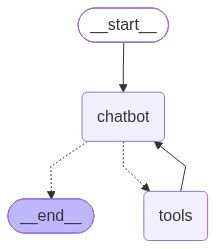

In [54]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [76]:
user_input="Hi there!, My name is nabila"

events=graph.stream(
     {"messages": [("user", user_input)]},stream_mode="values"
)

for event in events:
  event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there!, My name is nabila
================================== Ai Message ==================================

Hi Nabila! It's nice to meet you. How can I help you today?


In [77]:
user_input = "what is RLHF."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", user_input)]},stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is RLHF.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (x6fsh4wnq)
 Call ID: x6fsh4wnq
  Args:
    query: RLHF reinforcement learning from human feedback
================================= Tool Message =================================
Name: wikipedia

Page: Reinforcement learning from human feedback
Summary: In machine learning, reinforcement learning from human feedback (RLHF) is a technique to align an intelligent agent with human preferences. It involves training a reward model to represent preferences, which can then be used to train other mo
================================== Ai Message ==================================

**Reinforcement Learning from Human Feedback (RLHF)** is a technique in machine learning used to align AI models (like large language models) with human preferences and values.

### How it works (in three main steps):

